# Bayesian Uncertainty Minimization


In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

sys.path.append("../..")
import gpder 
from gpder import UncertaintyOptimization
from gpder.bayes.minimizers import hybrid_minimizer

from utils import plot_gpr_evolution, plot_gpr_iterloss

In [2]:
import sys 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sys.path.append("../..")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware

try:
    import uproot
except:
    print("uproot must be installed to run this demo.")

In [3]:
f = uproot.open("./three_jets.root")
tree = f['tnt']

njets = np.array(tree['nj'])
njets_cut = np.where(njets < 4)

j1_threeM = np.stack((np.array(tree['j1_pt'])[njets_cut],
                      np.array(tree['j1_eta'])[njets_cut],
                      np.array(tree['j1_phi'])[njets_cut]), axis=1)

j2_threeM = np.stack((np.array(tree['j2_pt'])[njets_cut],
                      np.array(tree['j2_eta'])[njets_cut],
                      np.array(tree['j2_phi'])[njets_cut]), axis=1)

j3_threeM = np.stack((np.array(tree['j3_pt'])[njets_cut],
                      np.array(tree['j3_eta'])[njets_cut],
                      np.array(tree['j3_phi'])[njets_cut]), axis=1)

f.close()

In [4]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))

In [5]:
def Eff_MET50_sigmoid(J_scale, j_scale, 
                      j1_threeM=j1_threeM, 
                      j2_threeM=j2_threeM, 
                      j3_threeM=j3_threeM):
    count_met = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            count_met += sigmoid(-(met-50.0))

    return count_met / count_pTcut

### Regular GPR

In [6]:
# -- training points -- # 
nu_a_train = [0.9, 1.0, 1.0, 1.0, 1.1]
nu_j_train = [1.0, 0.9, 1.0, 1.1, 1.0]
X_train = np.vstack((nu_a_train, nu_j_train)).T

y_train = np.array([Eff_MET50_sigmoid(X_train[i][0], 
                                      X_train[i][1]) for i in range(len(X_train))])
y_train_sig = np.array([Eff_MET50_sigmoid(X_train[i][0], 
                                          X_train[i][1]) for i in range(len(X_train))])

# -- testing points -- # 
res=10
X_lower = 0.7
X_upper = 1.3
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])
y_test_sig = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])

| Iter | J_scale   | j_scale   | Target    | MSE val   | Uncert val|
| 1    | 0.900000  | 1.000000  | 0.580745  | 0.047238  | 2.292281  |
| 2    | 1.000000  | 0.900000  | 0.787183  | 0.047238  | 2.292281  |
| 3    | 1.000000  | 1.000000  | 0.780826  | 0.047238  | 2.292281  |
| 4    | 1.000000  | 1.100000  | 0.661358  | 0.047238  | 2.292281  |
| 5    | 1.100000  | 1.000000  | 0.834261  | 0.047238  | 2.292281  |
| 6    | 0.700000  | 0.700000  | 0.489795  | 0.122088  | 0.666138  |
| 7    | 0.700000  | 0.702434  | 0.491195  | 0.123243  | 0.531925  |
| 8    | 0.935677  | 0.939965  | 0.755031  | 0.113809  | 0.766550  |
| 9    | 0.700000  | 0.700253  | 0.489462  | 0.016888  | 3.125241  |
| 10   | 1.300000  | 0.700000  | 0.278706  | 0.017287  | 2.386180  |
| 11   | 1.298589  | 1.297822  | 0.833433  | 0.020601  | 1.481204  |
| 12   | 0.700000  | 1.211296  | 0.001475  | 0.030892  | 0.398477  |
| 13   | 0.995537  | 1.300000  | 0.190333  | 0.008379  | 0.943502  |


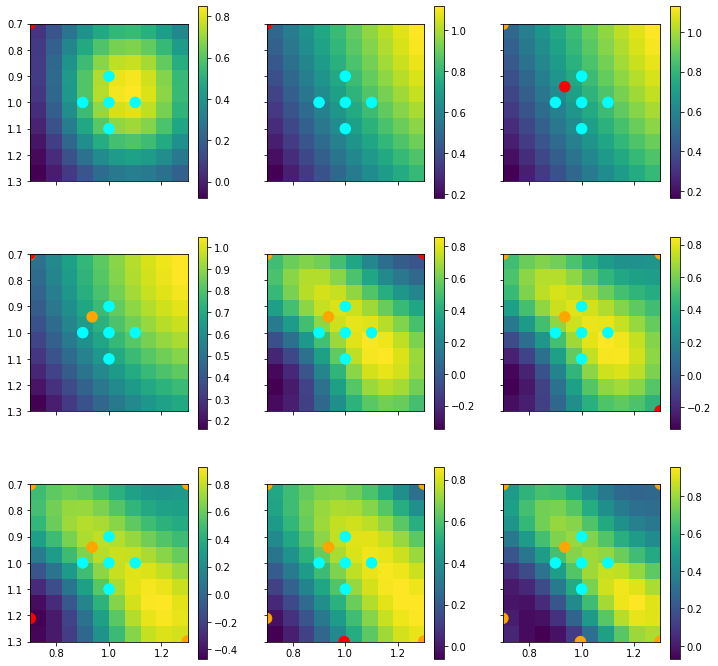

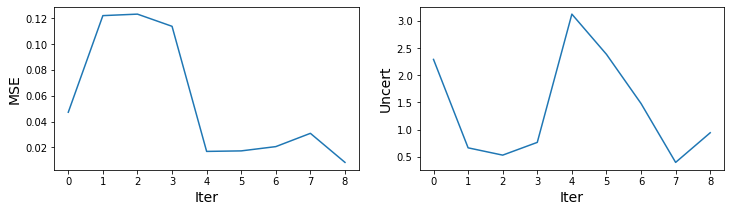

In [7]:
bayes = UncertaintyOptimization(fun=Eff_MET50_sigmoid,
                                ignore_convergence_warnings=True,
                                verbose=True,
                                param_bounds={'J_scale': (X_lower, X_upper), 
                                              'j_scale': (X_lower, X_upper)},
                                random_state=123)
bayes.minimize_uncertainty(params_train=X_train,
                           #minimizer=minimizer,
                           params_val=X_test,
                           niters=8,
                           minimizer_restarts=5,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes), 
                   X_lower=X_lower, X_upper=X_upper,
                   saveto="regular_evol")
plot_gpr_iterloss(bayes=copy.deepcopy(bayes),
                  saveto="regular_loss")

### With derivatives

In [8]:
def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

In [9]:
def dEff_MET50_sigmoid(J_scale, j_scale, 
              j1_threeM=j1_threeM, j2_threeM=j2_threeM, j3_threeM=j3_threeM):
    dmet_dj1 = 0
    dmet_dj2j3 = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            dsig = -dsigmoid(-(met-50.0))
            dmet = 0.5 / met

            # wrt J_scale 
            dj1  = -2*met_x*j1_threeM[i, 0] * np.cos(j1_threeM[i, 2]) / J_scale**2
            dj1 += -2*met_y*j1_threeM[i, 0] * np.sin(j1_threeM[i, 2]) / J_scale**2
            # wrt j_scale
            dj2j3  = -2*met_x*j2_threeM[i, 0] * np.cos(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_x*j3_threeM[i, 0] * np.cos(j3_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j2_threeM[i, 0] * np.sin(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j3_threeM[i, 0] * np.sin(j3_threeM[i, 2]) / j_scale**2

            dmet_dj1   += dsig * dmet * dj1
            dmet_dj2j3 += dsig * dmet * dj2j3

    return [dmet_dj1 / count_pTcut, dmet_dj2j3 / count_pTcut]


In [10]:
dX_train = X_train
dy_train_sig = np.array([dEff_MET50_sigmoid(dX_train[i][0], 
                                            dX_train[i][1]) for i in range(len(dX_train))])

| Iter | J_scale   | j_scale   | Target    | MSE val   | Uncert val|
| 1    | 0.900000  | 1.000000  | 0.580745  | 0.030892  | 2.659504  |
| 2    | 1.000000  | 0.900000  | 0.787183  | 0.030892  | 2.659504  |
| 3    | 1.000000  | 1.000000  | 0.780826  | 0.030892  | 2.659504  |
| 4    | 1.000000  | 1.100000  | 0.661358  | 0.030892  | 2.659504  |
| 5    | 1.100000  | 1.000000  | 0.834261  | 0.030892  | 2.659504  |
| 6    | 0.700000  | 1.300000  | 0.001049  | 0.009213  | 1.920521  |
| 7    | 1.300000  | 1.300000  | 0.832180  | 0.008313  | 1.219186  |
| 8    | 0.700000  | 0.700000  | 0.489795  | 0.011668  | 0.583197  |
| 9    | 0.988792  | 0.771875  | 0.454656  | 0.011704  | 0.706012  |
| 10   | 1.300000  | 0.700000  | 0.278706  | 0.003999  | 0.325676  |
| 11   | 0.700000  | 1.168175  | 0.003436  | 0.003508  | 0.247593  |
| 12   | 0.762635  | 1.299999  | 0.002614  | 0.003586  | 0.189736  |
| 13   | 1.300000  | 1.044782  | 0.597056  | 0.002628  | 0.123402  |


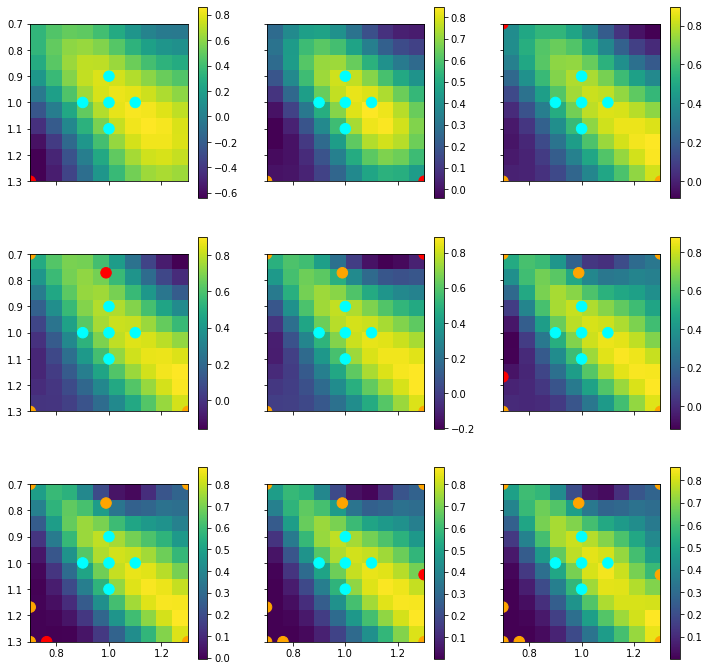

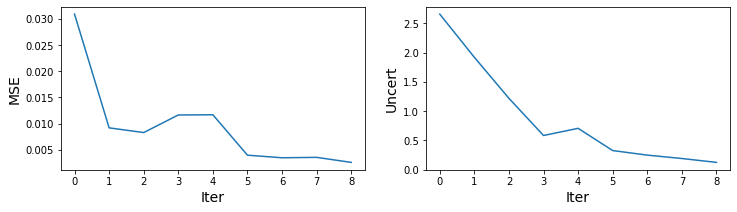

In [11]:
bayes_der = UncertaintyOptimization(fun=Eff_MET50_sigmoid,
                                dfun=dEff_MET50_sigmoid,
                                ignore_convergence_warnings=True,
                                verbose=True,
                                param_bounds={'J_scale': (X_lower, X_upper), 
                                              'j_scale': (X_lower, X_upper)},
                                random_state=123)
bayes_der.minimize_uncertainty(params_train=X_train,
                           params_val=X_test,
                           niters=8,
                           minimizer_restarts=5,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes_der), 
                   X_lower=X_lower, X_upper=X_upper,
                   saveto="derivative_evol")
plot_gpr_iterloss(bayes=copy.deepcopy(bayes_der),
                  saveto="derivative_loss")

##### Grid

In [16]:
from matplotlib.patches import Circle

In [17]:
X_grid = np.array(([0.7, 0.7], [0.7, 1.0], [0.7, 1.3],
                   [1.0, 0.7], [1.0, 1.3],
                   [1.3, 0.7], [1.3, 1.0], [1.3, 1.3])).reshape(-1, 2)
X_conc = np.concatenate((X_train, X_grid))

y_conc = bayes_der._eval_fun(X_conc)
dX_conc = X_conc
dy_conc = bayes_der._eval_dfun(dX_conc)

MSE:  0.001971798135246517
Uncert:  0.28443174666644355


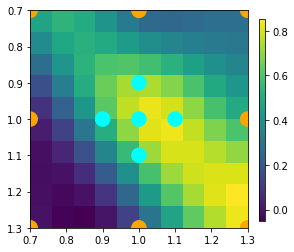

In [20]:
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_conc, y=y_conc, 
       dX=dX_conc, dy=dy_conc)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test_sig)

print("MSE: ", mse)
print("Uncert: ", np.trace(cov))

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(mu.reshape(res, res), 
           origin='upper', 
           extent=[X_lower, X_upper, X_upper, X_lower])
patches_init = [Circle((bayes_der.init_params[i, 0], bayes_der.init_params[i, 1]),
                radius=0.02, color='cyan') for i in range(5)]
for patch in patches_init:
    ax.add_patch(patch)
for i in range(8):
    ax.add_patch(Circle((X_grid[i, 0], X_grid[i, 1]), 
                 radius=0.02, color='orange'))
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("uniform.png", bbox_inches='tight')
plt.show()

MSE:  0.00262760150222877
Uncert:  0.12340150930466667


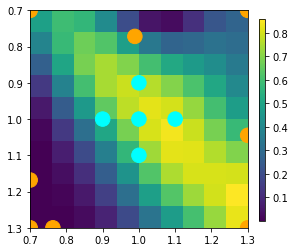

In [57]:
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=bayes_der.params, y=bayes_der.targets, 
       dX=bayes_der.params, dy=bayes_der.dtargets)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test_sig)
uncert = np.trace(cov)

print("MSE: ", mse)
print("Uncert: ", np.trace(cov))

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(mu.reshape(res, res), 
           origin='upper', 
           extent=[X_lower, X_upper, X_upper, X_lower])
patches_init = [Circle((bayes_der.init_params[i, 0], bayes_der.init_params[i, 1]),
                radius=0.02, color='cyan') for i in range(5)]
for patch in patches_init:
    ax.add_patch(patch)
for i in range(8):
    ax.add_patch(Circle((bayes_der.bayes_params[i, 0], bayes_der.bayes_params[i, 1]), 
                 radius=0.02, color='orange'))
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("bayes_der.png", bbox_inches='tight')
plt.show()

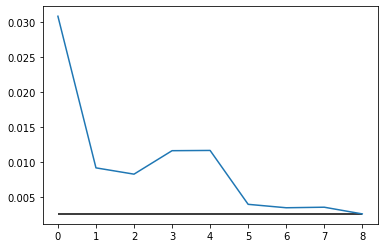

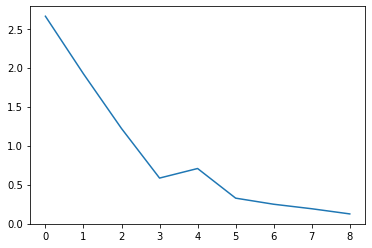

In [35]:
plt.plot(bayes_der.mse_val)
plt.hlines(mse, 0, 8)
plt.show()

plt.plot(bayes_der.uncert_val)
plt.show()

In [39]:
print(bayes.mse_val)
print(bayes.uncert_val)

[[0.04723806]
 [0.12208753]
 [0.12324337]
 [0.11380868]
 [0.01688761]
 [0.01728672]
 [0.02060096]
 [0.03089174]
 [0.00837912]]
[[2.29228062]
 [0.66613773]
 [0.53192505]
 [0.76655014]
 [3.12524116]
 [2.38617952]
 [1.48120446]
 [0.39847663]
 [0.9435018 ]]


In [38]:
print(bayes_der.mse_val)
print(bayes_der.uncert_val)

[[0.03089243]
 [0.00921285]
 [0.00831325]
 [0.01166803]
 [0.01170414]
 [0.00399883]
 [0.00350816]
 [0.00358619]
 [0.0026276 ]]
[[2.6595043 ]
 [1.92052054]
 [1.21918559]
 [0.58319683]
 [0.7060121 ]
 [0.32567589]
 [0.24759341]
 [0.1897357 ]
 [0.12340154]]


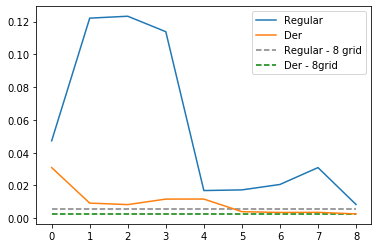

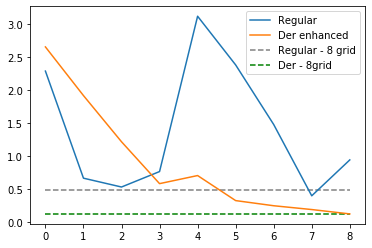

In [62]:
plt.plot(bayes.mse_val, label='Regular')
plt.plot(bayes_der.mse_val, label='Der')
plt.hlines(mse_reg, 0, 8, linestyle='--', color='gray', label='Regular - 8 grid')
plt.hlines(mse, 0, 8, linestyle='--', color='g', label='Der - 8grid')
plt.legend()
plt.savefig("comparison_mse.png", bbox_inches='tight')
plt.show()

plt.plot(bayes.uncert_val, label='Regular')
plt.plot(bayes_der.uncert_val, label='Der enhanced')
plt.hlines(uncert_reg, 0, 8, linestyle='--', color='gray', label='Regular - 8 grid')
plt.hlines(uncert, 0, 8, linestyle='--', color='g', label='Der - 8grid')
plt.legend()
plt.savefig("comparison_uncert.png", bbox_inches='tight')
plt.show()

MSE:  0.005355408024707772
Uncert:  0.48164206713355445


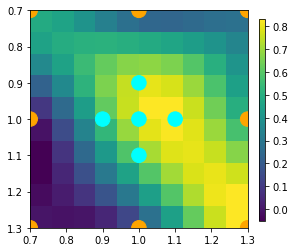

In [60]:
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_conc, y=y_conc)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse_reg = mean_squared_error(mu, y_test_sig)
uncert_reg = np.trace(cov)

print("MSE: ", mse_reg)
print("Uncert: ", np.trace(cov))

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(mu.reshape(res, res), 
           origin='upper', 
           extent=[X_lower, X_upper, X_upper, X_lower])
patches_init = [Circle((bayes_der.init_params[i, 0], bayes_der.init_params[i, 1]),
                radius=0.02, color='cyan') for i in range(5)]
for patch in patches_init:
    ax.add_patch(patch)
for i in range(8):
    ax.add_patch(Circle((X_grid[i, 0], X_grid[i, 1]), 
                 radius=0.02, color='orange'))
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("uniform.png", bbox_inches='tight')
plt.show()

In [46]:
mse

0.00262760150222877